<a href="https://colab.research.google.com/github/gaegoori/5th-diet-ai/blob/RAG/%EC%B5%9C%EC%A2%85_RAG_%EC%99%84%EC%84%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1: 라이브러리 설치 (rank_bm25 추가)
%%capture
!pip install transformers accelerate bitsandbytes peft
!pip install chromadb sentence-transformers pypdf langchain-text-splitters rank_bm25

print("✅ 설치 완료!")

In [2]:
# STEP 2: 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# STEP 3: 라이브러리 임포트

import os
import re
import torch
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
from pypdf import PdfReader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from rank_bm25 import BM25Okapi
from typing import List, Dict
import warnings
warnings.filterwarnings('ignore')

print("✅ 라이브러리 로드 완료!")

✅ 라이브러리 로드 완료!


In [4]:
# STEP 4: PDF 처리 클래스 (법률 문서 최적화 버전)
import re
from pypdf import PdfReader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import List, Dict

class PDFProcessor:
    def __init__(self, chunk_size=700, chunk_overlap=150):
        # 💡 법률 문서의 핵심인 '제O조' 단위로 잘리도록 구분자(separators)에 "\n제" 추가
        self.text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=["\n제", "\n\n", "\n", ". ", " ", ""]
        )

    def process_pdf(self, pdf_path: str) -> List[Dict]:
        print(f"PDF 처리 중: {pdf_path}")
        chunks_with_meta = []
        try:
            reader = PdfReader(pdf_path)
            for page_num, page in enumerate(reader.pages, 1):
                extracted = page.extract_text()
                if extracted:
                    # 띄어쓰기 2개 이상은 1개로 줄이되, 줄바꿈은 유지
                    text = re.sub(r' +', ' ', extracted)
                    # '제X조' 앞에 줄바꿈이 없으면 강제로 넣어주어 스플리터가 인식하게 함
                    text = re.sub(r'(?<!\n)(제\d+조)', r'\n\1', text)

                    for chunk in self.text_splitter.split_text(text):
                        chunk = chunk.strip()
                        if len(chunk) > 10: # 너무 짧은 의미 없는 텍스트는 제외
                            chunks_with_meta.append({
                                "text": chunk,
                                "page": page_num
                            })
            print(f"{len(chunks_with_meta)}개의 청크로 분할 완료.")
            return chunks_with_meta
        except Exception as e:
            print(f"PDF 읽기 오류: {pdf_path} - {e}")
            return []

print("PDFProcessor 정의 완료 (법률 최적화)")

PDFProcessor 정의 완료 (법률 최적화)


In [5]:
# STEP 5: 벡터 DB 클래스 (가중치 조정 및 페이지 정보 추가)
class EnsembleVectorStore:
    def __init__(self, persist_directory: str = "/content/drive/MyDrive/chroma_db"):
        self.persist_directory = persist_directory
        os.makedirs(persist_directory, exist_ok=True)

        print("임베딩 모델 로딩 중...")
        self.embedding_model = SentenceTransformer(
            'jhgan/ko-sroberta-multitask',
            device='cuda' if torch.cuda.is_available() else 'cpu'
        )
        print("임베딩 모델 로드 완료.")

        self.client = chromadb.PersistentClient(
            path=persist_directory,
            settings=Settings(anonymized_telemetry=False, allow_reset=True)
        )

        self.collection = self.client.get_or_create_collection(
            name="legal_docs",
            metadata={"hnsw:space": "cosine"}
        )

        self.documents = []
        self.metadatas = []
        self.bm25 = None
        self._sync_bm25()
        print(f"벡터 DB 로드 완료. (현재 문서 수: {self.collection.count()})")

    def _tokenize(self, text: str) -> List[str]:
        text = re.sub(r'[^\w\s]', '', text)
        return text.split()

    def _sync_bm25(self):
        data = self.collection.get()
        if data['documents']:
            self.documents = data['documents']
            self.metadatas = data['metadatas']
            tokenized_corpus = [self._tokenize(doc) for doc in self.documents]
            self.bm25 = BM25Okapi(tokenized_corpus)
        else:
            self.documents = []
            self.metadatas = []
            self.bm25 = None

    def add_documents(self, chunks_with_meta: List[Dict], source: str = "unknown"):
        if not chunks_with_meta:
            return

        print(f"{len(chunks_with_meta)}개 청크를 벡터 DB에 추가 중...")
        texts = [item["text"] for item in chunks_with_meta]
        embeddings = self.embedding_model.encode(
            texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True
        )

        existing_count = self.collection.count()
        ids = [f"{source}_{existing_count + i}" for i in range(len(texts))]
        metadatas = [{"source": source, "page": item.get("page", 0), "chunk_id": existing_count + i} for i, item in enumerate(chunks_with_meta)]

        try:
            self.collection.add(
                embeddings=embeddings.tolist(), documents=texts, metadatas=metadatas, ids=ids
            )
            self._sync_bm25()
            print(f"벡터 DB 및 BM25 저장 완료. (총 {self.collection.count()}개 문서)")
        except Exception as e:
            print(f"저장 오류: {e}")

    def search(self, query: str, top_k: int = 3, dense_weight: float = 0.8, sparse_weight: float = 0.2) -> List[Dict]:
        if self.collection.count() == 0 or not self.bm25:
            print("데이터베이스가 비어있습니다.")
            return []

        search_k = min(top_k * 3, len(self.documents))

        # 1. Dense Search
        query_embedding = self.embedding_model.encode([query], convert_to_numpy=True)[0]
        dense_results = self.collection.query(
            query_embeddings=[query_embedding.tolist()],
            n_results=search_k
        )
        dense_docs = dense_results['documents'][0]
        dense_metas = dense_results['metadatas'][0]

        # 2. Sparse Search
        tokenized_query = self._tokenize(query)
        bm25_scores = self.bm25.get_scores(tokenized_query)
        bm25_top_indices = np.argsort(bm25_scores)[::-1][:search_k]

        # 3. Weighted RRF
        rrf_scores = {}
        k_rrf = 60

        for rank, (doc, meta) in enumerate(zip(dense_docs, dense_metas)):
            rrf_scores[doc] = {
                "score": dense_weight * (1.0 / (k_rrf + rank + 1)),
                "source": meta['source'],
                "page": meta.get('page', '알수없음'),
                "content": doc
            }

        for rank, idx in enumerate(bm25_top_indices):
            doc = self.documents[idx]
            meta = self.metadatas[idx]
            sparse_score = sparse_weight * (1.0 / (k_rrf + rank + 1))
            if doc in rrf_scores:
                rrf_scores[doc]["score"] += sparse_score
            else:
                rrf_scores[doc] = {
                    "score": sparse_score,
                    "source": meta['source'],
                    "page": meta.get('page', '알수없음'),
                    "content": doc
                }

        sorted_results = sorted(rrf_scores.values(), key=lambda x: x["score"], reverse=True)[:top_k]
        return sorted_results

In [6]:
# STEP 6: 모델 로드
def load_model(model_path: str):
    print("🔄 모델 로딩 중...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )

    base_model_name = "Qwen/Qwen2.5-3B-Instruct"

    model = AutoModelForCausalLM.from_pretrained(
        base_model_name, quantization_config=bnb_config, device_map="auto", trust_remote_code=True
    )
    tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)

    if os.path.exists(model_path):
        try:
            model = PeftModel.from_pretrained(model, model_path)
            print(f"✅ LoRA 어댑터 로드 완료: {model_path}")
        except Exception as e:
            print(f"⚠️  어댑터 로드 실패: {e}")
    else:
        print("→ 베이스 모델만 사용합니다.")

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
    tokenizer.padding_side = "left"

    print("✅ 모델 준비 완료!")
    return model, tokenizer

In [7]:
# STEP 7: RAG 파이프라인 (스트리밍, 환각 차단, 무한 반복 방지 완벽 적용 버전)
import torch
import re
from transformers import TextIteratorStreamer
from threading import Thread

class RAGPipeline:
    def __init__(self, model, tokenizer, vector_store):
        self.model = model
        self.tokenizer = tokenizer
        self.vector_store = vector_store
        self.model.eval()

    def rewrite_query(self, question: str) -> str:
        # 💡 개선: 법률 용어의 원형을 보존하고 검색에 유리한 명사형 키워드로 변환
        prompt = (
            "당신은 법률 전문 검색어 최적화 AI입니다.\n"
            "사용자의 질문에서 법적 의무, 처벌, 절차와 관련된 '핵심 법률 용어'를 추출하여 검색용 쿼리로 재작성하십시오.\n"
            "반드시 한국어로만 작성하고, 부연 설명 없이 결과만 출력하십시오.\n\n"
            "[규칙]\n"
            "- '의무는 무엇인가요?' -> '공무원의 의무 규정 및 종류'\n"
            "- '처벌' -> '징계 종류 및 양정 기준'\n"
            "- 원본 질문에 '의무', '금지', '징계' 등 법률적 핵심 단어가 있다면 반드시 포함할 것.\n\n"
            f"질문: {question}\n"
            "재작성:"
        )

        messages = [
            {"role": "system", "content": "당신은 법률 검색 최적화 전문가입니다."},
            {"role": "user", "content": prompt}
        ]

        text = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = self.tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512).to("cuda")

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=40,
                temperature=0.1,
                do_sample=False,
                pad_token_id=self.tokenizer.pad_token_id,
                eos_token_id=self.tokenizer.eos_token_id,
            )

        rewritten = self.tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
        # "재작성:" 문자열이 포함된 경우 제거
        rewritten = rewritten.replace("재작성:", "").strip()
        return rewritten if len(rewritten) > 2 else question

    def generate_answer(self, question: str, top_k: int = 7, max_new_tokens: int = 1024):
        print(f"\n[1단계] 원본 질문: {question}")

        rewritten_question = self.rewrite_query(question)
        print(f"[2단계] 검색 쿼리: {rewritten_question}")

        # 💡 검색 시 앙상블 가중치 조절 가능 (필요 시 search 메서드 인자 수정)
        retrieved_docs = self.vector_store.search(rewritten_question, top_k=top_k)
        print(f"[3단계] 문서 검색 완료 ({len(retrieved_docs)}개)")

        if not retrieved_docs:
            context = "제공된 문서에서 관련 내용을 찾을 수 없습니다."
        else:
            context = "\n\n".join([
                f"[참고문서: {doc['source']} / {doc['page']}페이지]\n{doc['content']}"
                for doc in retrieved_docs
            ])

        # 💡 개선: 시스템 프롬프트를 '법률 전문가' 페르소나로 강화
        messages = [
            {
                "role": "system",
                "content": (
                    "당신은 대한민국 법령(국가공무원법 등)에 해박한 전문 법률 AI입니다.\n\n"
                    "1. 반드시 제공된 [관련 법률 문서]의 내용만을 근거로 답변하십시오.\n"
                    "2. 답변 시 반드시 관련 조항 번호(예: 제56조)를 명시하십시오.\n"
                    "3. '의무'나 '금지사항'에 대한 질문에는 조문에 명시된 명칭(예: 성실 의무, 복종의 의무 등)을 중심으로 구조화하여 답변하십시오.\n"
                    "4. 문서에 없는 내용을 지어내거나 '제 생각에는'과 같은 표현을 쓰지 마십시오.\n"
                    "5. 관련 근거가 전혀 없다면 '제공된 문서에서 명확한 근거를 찾을 수 없습니다'라고 답변하십시오."
                )
            },
            {
                "role": "user",
                "content": f"[관련 법률 문서]\n{context}\n\n[질문]\n{question}"
            }
        ]

        text = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = self.tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=3500).to("cuda")

        streamer = TextIteratorStreamer(self.tokenizer, skip_prompt=True, skip_special_tokens=True)

        generation_kwargs = dict(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=False,
            repetition_penalty=1.1, # 반복 방지 강화
            pad_token_id=self.tokenizer.pad_token_id,
            eos_token_id=self.tokenizer.eos_token_id,
            streamer=streamer
        )

        thread = Thread(target=self.model.generate, kwargs=generation_kwargs)
        thread.start()

        answer = ""
        for new_text in streamer:
            answer += new_text
            yield {
                "question": question,
                "rewritten_question": rewritten_question,
                "answer": answer,
                "sources": retrieved_docs
            }

print("✅ STEP 7: 개선된 RAG 파이프라인 정의 완료")

✅ STEP 7: 개선된 RAG 파이프라인 정의 완료


In [8]:
# STEP 8: 대화형 인터페이스
def interactive_rag(rag_pipeline, vector_store):
    print("\n" + "=" * 70)
    print("🤖 법률 AI 어시스턴트 (앙상블 RAG 모드)")
    print("=" * 70)
    print(f"📊 벡터 DB: {vector_store.collection.count()}개 문서")
    print("💡 명령어: 'exit' (종료), 'status' (상태)")
    print("=" * 70 + "\n")

    while True:
        try:
            question = input("❓ 질문: ").strip()

            if question.lower() in ['exit', '종료', 'quit', 'q']:
                print("\n👋 종료!")
                break

            if not question:
                continue

            result = rag_pipeline.generate_answer(question, top_k=6)

            print("\n" + "-" * 70)
            print("🤖 답변:")
            print("-" * 70)
            print(result['answer'])

            if result['sources']:
                print("\n📚 참고 문서 (RRF 앙상블 점수 기반):")
                for i, source in enumerate(result['sources'], 1):
                    # 앙상블 서치이므로 % 대신 RRF Score 출력
                    print(f"{i}. {source['source']} (Score: {source['score']:.4f})")
            print("-" * 70 + "\n")

        except KeyboardInterrupt:
            print("\n\n👋 종료!")
            break
        except Exception as e:
            print(f"\n❌ 오류: {e}\n")




In [12]:
# STEP 9: 실행부
PDF_FILES = [
    "/content/drive/MyDrive/국가공무원법(법률)(제20627호)(20250701).pdf",
    "/content/drive/MyDrive/초ㆍ중등교육법 시행령(대통령령)(제35856호)(20251125).pdf",
    "/content/drive/MyDrive/교육공무원법(법률)(제11381호)(20130301).pdf"
]

MODEL_PATH = "/content/drive/MyDrive/My-AI-Project/Qwen2.5-3B-Legal-LoRA/Qwen2.5-3B-Legal-LoRA"

# ✅ LegalPDFProcessor는 __init__ 인자 없음
pdf_processor = PDFProcessor()

vector_store = EnsembleVectorStore(persist_directory="/content/drive/MyDrive/chroma_db")

for pdf_path in PDF_FILES:
    chunks = pdf_processor.process_pdf(pdf_path)
    if chunks:
        vector_store.add_documents(chunks, source=os.path.basename(pdf_path))

model, tokenizer = load_model(MODEL_PATH)
final_rag = RAGPipeline(model, tokenizer, vector_store)

print("✅ 모든 초기화 완료!")

임베딩 모델 로딩 중...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


임베딩 모델 로드 완료.
벡터 DB 로드 완료. (현재 문서 수: 0)
PDF 처리 중: /content/drive/MyDrive/국가공무원법(법률)(제20627호)(20250701).pdf
147개의 청크로 분할 완료.
147개 청크를 벡터 DB에 추가 중...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

...

벡터 DB 및 BM25 저장 완료. (총 418개 문서)
PDF 처리 중: /content/drive/MyDrive/교육공무원법(법률)(제11381호)(20130301).pdf
64개의 청크로 분할 완료.
64개 청크를 벡터 DB에 추가 중...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

벡터 DB 및 BM25 저장 완료. (총 482개 문서)
🔄 모델 로딩 중...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

✅ LoRA 어댑터 로드 완료: /content/drive/MyDrive/My-AI-Project/Qwen2.5-3B-Legal-LoRA/Qwen2.5-3B-Legal-LoRA
✅ 모델 준비 완료!
✅ 모든 초기화 완료!


In [ ]:
# STEP 10: Gradio UI
import gradio as gr
import os
import traceback
import types

processed_pdfs = set()

def upload_and_process_pdf(pdf_files):
    if not pdf_files:
        return "PDF 파일을 업로드해주세요."

    results = []
    for pdf_file in pdf_files:
        pdf_path = getattr(pdf_file, "name", str(pdf_file))
        file_name = os.path.basename(pdf_path)

        if file_name in processed_pdfs:
            results.append(f"[중복] 이미 처리된 파일입니다: {file_name}")
            continue

        try:
            if 'pdf_processor' not in globals() or 'vector_store' not in globals():
                return "파이프라인 초기화 셀을 먼저 실행해주세요."

            chunks_with_meta = pdf_processor.process_pdf(pdf_path)
            if chunks_with_meta:
                vector_store.add_documents(chunks_with_meta, source=file_name)
                processed_pdfs.add(file_name)
                results.append(f"처리 완료: {file_name}  ({len(chunks_with_meta)}개 청크)")
            else:
                results.append(f"텍스트 추출 실패: {file_name}")
        except Exception as e:
            results.append(f"오류 ({file_name}): {str(e)}")

    if 'vector_store' in globals():
        results.append(f"\n현재 벡터 DB 총 문서 수: {vector_store.collection.count()}개")

    return "\n".join(results)


def ask_question(question):
    try:
        if not question or not str(question).strip():
            return "질문을 입력해주세요."

        if 'vector_store' not in globals() or 'final_rag' not in globals():
            return "파이프라인 초기화 셀을 먼저 실행해주세요."

        if vector_store.collection.count() == 0:
            return "먼저 PDF를 업로드해 주세요."

        response = final_rag.generate_answer(str(question), top_k=7)

        result = None
        if isinstance(response, types.GeneratorType):
            for res in response:
                result = res
        else:
            result = response

        answer_text = result['answer']

        if result['rewritten_question'] != question:
            answer_text = f"[검색 쿼리: {result['rewritten_question']}]\n\n" + answer_text

        if result.get('sources'):
            answer_text += "\n\n---\n참고 문서 (RRF 앙상블 점수 기준):\n"
            for i, src in enumerate(result['sources'], 1):
                page  = src.get('page', '?')
                score = src.get('score', 0)
                answer_text += f"  {i}. {src['source']}  {page}페이지  (점수: {score:.4f})\n"

        return answer_text

    except Exception as e:
        print(traceback.format_exc())
        return f"오류: {str(e)}"


def get_db_status():
    try:
        if 'vector_store' not in globals():
            return "파이프라인 초기화 셀을 먼저 실행해주세요."
        count = vector_store.collection.count()
        if count == 0:
            return "벡터 DB가 비어있습니다."
        files = list(processed_pdfs) if processed_pdfs else ["(이전 세션에서 로드된 문서 포함)"]
        status = f"총 {count}개 청크 저장됨\n\n처리된 파일:\n"
        for f in files:
            status += f"  - {f}\n"
        return status
    except Exception as e:
        return f"오류: {str(e)}"


def clear_database():
    try:
        if 'vector_store' not in globals():
            return "파이프라인 초기화 셀을 먼저 실행해주세요."
        vector_store.client.delete_collection("legal_docs")
        vector_store.collection = vector_store.client.create_collection(
            name="legal_docs",
            metadata={"hnsw:space": "cosine"}
        )
        vector_store.documents = []
        vector_store.metadatas = []
        vector_store.bm25 = None
        processed_pdfs.clear()
        return "벡터 DB 및 BM25 인덱스 초기화 완료."
    except Exception as e:
        return f"초기화 오류: {str(e)}"


with gr.Blocks(title="문서 검색 시스템", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 법률 문서 검색 시스템
      """)

    with gr.Tab("PDF 업로드"):
        gr.Markdown("### PDF 파일 업로드 (여러 개 동시 가능)")
        pdf_input = gr.File(label="PDF 파일 선택", file_types=[".pdf"], file_count="multiple")
        upload_btn = gr.Button("업로드 및 처리", variant="primary")
        upload_result = gr.Textbox(label="처리 결과", lines=6, interactive=False)
        upload_btn.click(fn=upload_and_process_pdf, inputs=[pdf_input], outputs=[upload_result])

    with gr.Tab("질문하기"):
      gr.Markdown("### 업로드한 PDF 내용을 기반으로 질문하세요")
      question_input = gr.Textbox(
          label="질문 입력",
          placeholder="예: 공무원이 허가 없이 영리 업무를 하면 어떤 징계를 받나요?",
          lines=3
      )
      ask_btn = gr.Button("답변 생성", variant="primary")
      answer_output = gr.Textbox(label="답변", lines=18, interactive=False)
      gr.Examples(
          examples=[
              ["국가공무원법상 공무원의 영리업무 금지 조항은 무엇인가요?"],
              ["공무원의 의무는 무엇인가요?"],
              ["공무원이 직무와 관련하여 금품을 받으면 어떤 처벌을 받나요?"],
          ],
          inputs=question_input
      )
      ask_btn.click(fn=ask_question, inputs=[question_input], outputs=[answer_output])
      question_input.submit(fn=ask_question, inputs=[question_input], outputs=[answer_output])

    with gr.Tab("DB 상태"):
        gr.Markdown("### ChromaDB + BM25 현황")
        with gr.Row():
            status_btn = gr.Button("상태 확인", variant="secondary")
            clear_btn  = gr.Button("DB 초기화", variant="stop")
        status_output = gr.Textbox(label="DB 상태", lines=8, interactive=False)
        status_btn.click(fn=get_db_status, outputs=[status_output])
        clear_btn.click(fn=clear_database, outputs=[status_output])

demo.queue(default_concurrency_limit=2).launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b76cdd84b63ab376dc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


PDF 처리 중: /tmp/gradio/b7c514e2700a992bc51104c2fa19f8660347e1174796bba60ef82632257fcbf0/국가공무원법법률제20627호20250701 2.pdf
147개의 청크로 분할 완료.
147개 청크를 벡터 DB에 추가 중...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

벡터 DB 및 BM25 저장 완료. (총 629개 문서)

[1단계] 원본 질문: 국가공무원법상 공무원의 영리업무 금지 조항은 무엇인가요?
[2단계] 검색 쿼리: - **질의 원본**: 국가공무원법상 공무원의 영리업무 금지 조항은 무엇인가요?

- **검색 쿼리
[3단계] 문서 검색 완료 (7개)
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://b76cdd84b63ab376dc.gradio.live


In [10]:
# 벡터DB 리셋 > 필요 시에만 작동시키세요

vector_store.client.delete_collection("legal_docs")
vector_store.collection = vector_store.client.create_collection(
    name="legal_docs",
    metadata={"hnsw:space": "cosine"}
)
print(f"완료. 현재 문서 수: {vector_store.collection.count()}")

완료. 현재 문서 수: 0


In [11]:
%%capture
!pip install ragas datasets langchain-openai

In [ ]:
import os, glob, json
from datasets import Dataset

folder_path = '/content/drive/MyDrive/My-AI-Project/Validation/Validation/'
file_list = glob.glob(os.path.join(folder_path, '*.json*'))[:10]
data_samples = {
    'user_input':         [],
    'response':           [],
    'retrieved_contexts': [],
    'reference':          []
}

print(f'🔄 총 {len(file_list)}개 JSON 파일 처리 시작...')

for file_path in file_list:
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        if 'label' not in data:
            continue

        q  = data['label'].get('input',  '').strip()
        gt = data['label'].get('output', '').strip()
        if not q:
            continue

        final_result = None
        for result in final_rag.generate_answer(q, top_k=5):
            final_result = result

        data_samples['user_input'].append(final_result['question'])
        data_samples['response'].append(final_result['answer'])
        data_samples['retrieved_contexts'].append(
            [doc['content'] for doc in final_result['sources']]
        )
        data_samples['reference'].append(gt)

    except Exception as e:
        print(f'  ⚠️  오류 ({os.path.basename(file_path)}): {e}')

eval_dataset = Dataset.from_dict(data_samples)
print(f'✅ 데이터셋 구축 완료: {len(eval_dataset)}개')

🔄 총 10개 JSON 파일 처리 시작...

[1단계] 원본 질문: 건축물의 일부를 용도변경하면서 추가로 주차대수를 확보해야 할 경우, 최초 사용승인 당시 초과하여 확보한 주차시설을 용도변경으로 인해 새롭게 필요한 주차시설로 대체할 수 있나요?
[2단계] 검색 쿼리: - 질의 내용: 건축물의 일부를 용도변경하면서 추가로 주차대수를 확보해야 하는 경우, 최초 사용승인 당시 초과하여 확
[3단계] 문서 검색 완료 (5개)

[1단계] 원본 질문: 완충녹지를 설치할 때 이면도로가 필요하다면, 도시관리계획을 결정할 때 이면도로 설치계획도 포함해야 하나요?
[2단계] 검색 쿼리: - **질의 원문**: "완충녹지를 설치할 때 이면도로가 필요하다면, 도시관리계획을 결정할 때 이면도로 설치계획도 포함
[3단계] 문서 검색 완료 (5개)

[1단계] 원본 질문: 사망보상금 지급 기준이 명확하지 않은 경우, 그 기준을 국가보훈처장이 정할 수 있나요?
[2단계] 검색 쿼리: 질문: 사망보상금 지급 기준이 불명확한 경우, 국가보훈처장이 이를 정할 수 있나요?
[3단계] 문서 검색 완료 (5개)

[1단계] 원본 질문: 관리지역 중 계획관리지역으로 구분되지 않은 지역의 농지를 제조업소 부지로 사용하려는 경우에도 농지전용허가를 거부할 수 있나요?
[2단계] 검색 쿼리: - **질문**: 관리지역 중 계획관리지역으로 구분되지 않은 지역의 농지를 제조업소 부지로 사용하려는 경우에도 �
[3단계] 문서 검색 완료 (5개)

[1단계] 원본 질문: 「건축법 시행령」 시행당시 바닥면적 160제곱미터의 사무소 용도로 사용하던 건축물에 멀티미디어 문화컨텐츠 설비제공업소를 설치하여 영업 중인 경우, 해당 건축물의 용도는 별표 1 제7호의 판매시설로 변경되는지요?
[2단계] 검색 쿼리: - **질의 내용**: 「건축법 시행령」 시행 당시 사무소 용도로 사용하던 건축물에 멀티미디어 문화컨텐츠 설
[3단계] 문서 검색 완료 (5개)

[1단계] 원본 질문: 일반고등학교에서 군인자녀를 대상으로 전국단위

In [15]:
import nest_asyncio
from google.colab import userdata
from ragas import evaluate
from ragas.metrics import Faithfulness, AnswerRelevancy
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

nest_asyncio.apply()
os.environ['OPENAI_API_KEY'] = userdata.get('GPT_API_KEY')

evaluator_llm        = LangchainLLMWrapper(ChatOpenAI(model='gpt-4o-mini'))
evaluator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

print('⚖️ RAGAS 평가 시작...')
evaluation_result = evaluate(
    dataset      = eval_dataset,
    metrics      = [Faithfulness(), AnswerRelevancy()],
    llm          = evaluator_llm,
    embeddings   = evaluator_embeddings,
    raise_exceptions = False
)

df_result = evaluation_result.to_pandas()
print(df_result[['user_input', 'faithfulness', 'answer_relevancy']].to_string())

⚖️ RAGAS 평가 시작...


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

                                                                                                              user_input  faithfulness  answer_relevancy
0                     건축물의 일부를 용도변경하면서 추가로 주차대수를 확보해야 할 경우, 최초 사용승인 당시 초과하여 확보한 주차시설을 용도변경으로 인해 새롭게 필요한 주차시설로 대체할 수 있나요?      0.142857          0.890664
1                                                            완충녹지를 설치할 때 이면도로가 필요하다면, 도시관리계획을 결정할 때 이면도로 설치계획도 포함해야 하나요?      0.473684          0.000000
2                                                                       사망보상금 지급 기준이 명확하지 않은 경우, 그 기준을 국가보훈처장이 정할 수 있나요?      0.700000          0.840672
3                                                 관리지역 중 계획관리지역으로 구분되지 않은 지역의 농지를 제조업소 부지로 사용하려는 경우에도 농지전용허가를 거부할 수 있나요?      0.777778          0.000000
4  「건축법 시행령」 시행당시 바닥면적 160제곱미터의 사무소 용도로 사용하던 건축물에 멀티미디어 문화컨텐츠 설비제공업소를 설치하여 영업 중인 경우, 해당 건축물의 용도는 별표 1 제7호의 판매시설로 변경되는지요?      0.000000          0.000000
5                                                                               일반

                      평균    표준편차  최솟값     중앙값     최댓값
faithfulness      0.4265  0.3039  0.0  0.4452  0.7778
answer_relevancy  0.4288  0.4528  0.0  0.3964  0.8958

── Faithfulness 등급
faithfulness_grade
C 미흡    4
B 보통    4
F 실패    2

── Answer Relevancy 등급
answer_relevancy_grade
F 실패    5
A 우수    4
B 보통    1

⚠️  동시 0점: 2개 (20.0%)
저장: /content/drive/MyDrive/My-AI-Project/ragas_fail_cases.csv


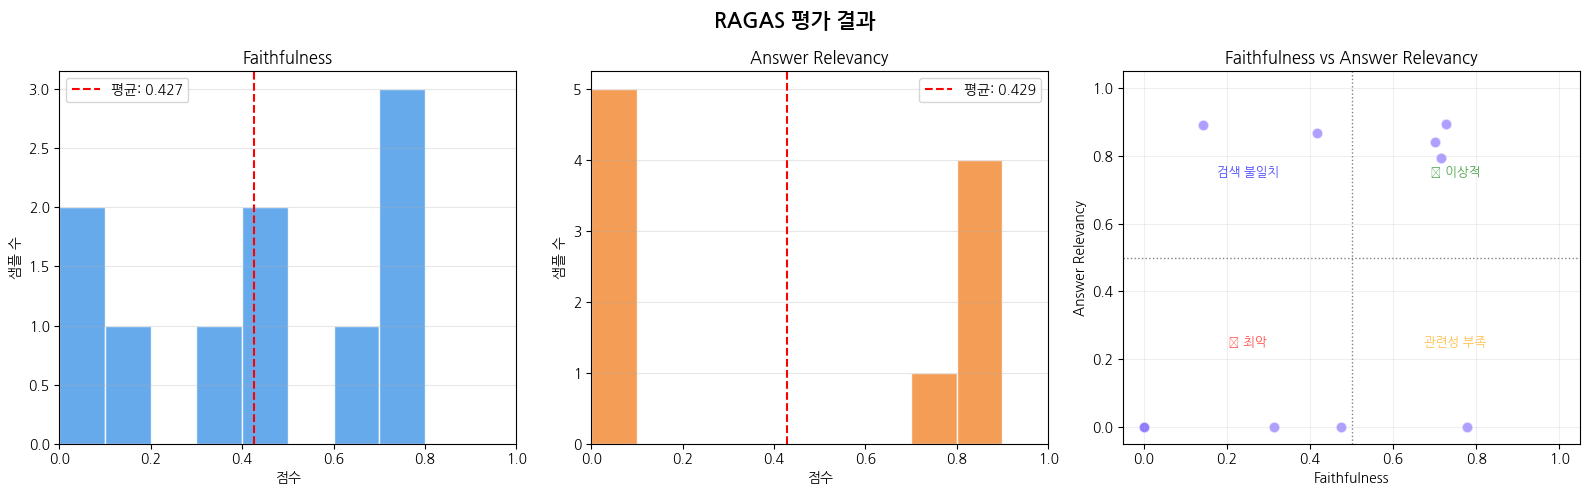


💡 개선 인사이트


In [16]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import subprocess

subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family']        = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

metrics_cols = ['faithfulness', 'answer_relevancy']

# 기본 통계
print('=' * 50)
summary = df_result[metrics_cols].describe().T[['mean','std','min','50%','max']]
summary.columns = ['평균','표준편차','최솟값','중앙값','최댓값']
print(summary.round(4))

# 등급 분류
def grade(s):
    if s >= 0.8: return 'A 우수'
    if s >= 0.5: return 'B 보통'
    if s  > 0.0: return 'C 미흡'
    return 'F 실패'

for col in metrics_cols:
    df_result[f'{col}_grade'] = df_result[col].fillna(0).apply(grade)

print('\n── Faithfulness 등급')
print(df_result['faithfulness_grade'].value_counts().to_string())
print('\n── Answer Relevancy 등급')
print(df_result['answer_relevancy_grade'].value_counts().to_string())

# 동시 실패 저장
both_fail = df_result[(df_result.faithfulness == 0) & (df_result.answer_relevancy == 0)]
fail_rate = len(both_fail) / len(df_result) * 100
print(f'\n⚠️  동시 0점: {len(both_fail)}개 ({fail_rate:.1f}%)')
fail_path = '/content/drive/MyDrive/My-AI-Project/ragas_fail_cases.csv'
both_fail.to_csv(fail_path, index=False, encoding='utf-8-sig')
print(f'저장: {fail_path}')

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RAGAS 평가 결과', fontsize=15, fontweight='bold')

for ax, col, color, label in zip(
    axes[:2],
    metrics_cols,
    ['#4C9BE8', '#F28C38'],
    ['Faithfulness', 'Answer Relevancy']
):
    vals = df_result[col].dropna()
    ax.hist(vals, bins=10, range=(0,1), color=color, edgecolor='white', alpha=0.85)
    ax.axvline(vals.mean(), color='red', linestyle='--', lw=1.5, label=f'평균: {vals.mean():.3f}')
    ax.set_title(label); ax.set_xlabel('점수'); ax.set_ylabel('샘플 수')
    ax.set_xlim(0,1); ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[2]
ax.scatter(df_result.faithfulness, df_result.answer_relevancy,
           alpha=0.6, c='#7B61FF', edgecolors='white', s=60)
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.axvline(0.5, color='gray', ls=':', lw=1)
for txt, x, y, c in [
    ('✅ 이상적',   0.75, 0.75, 'green'),
    ('❌ 최악',     0.25, 0.25, 'red'),
    ('관련성 부족', 0.75, 0.25, 'orange'),
    ('검색 불일치', 0.25, 0.75, 'blue')
]:
    ax.text(x, y, txt, ha='center', va='center', fontsize=9, color=c, alpha=0.7)
ax.set_title('Faithfulness vs Answer Relevancy')
ax.set_xlabel('Faithfulness'); ax.set_ylabel('Answer Relevancy')
ax.set_xlim(-0.05,1.05); ax.set_ylim(-0.05,1.05); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/My-AI-Project/ragas_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# 인사이트
f_mean = df_result.faithfulness.mean()
r_mean = df_result.answer_relevancy.mean()
print('\n' + '=' * 50 + '\n💡 개선 인사이트')
if fail_rate > 40:
    print(f'🔴 동시 실패율 {fail_rate:.0f}% → retrieval이 관련 문서를 못 찾는 케이스 많음')
    print('   청킹 크기 조정 / 임베딩 모델 교체 / top_k 증가 검토')
if f_mean < 0.4:
    print(f'🟡 Faithfulness {f_mean:.3f} → hallucination 발생 중, 프롬프트 강화 필요')
if r_mean < 0.4:
    print(f'🟡 Answer Relevancy {r_mean:.3f} → 빈 응답 패턴 점검 필요')
if f_mean >= 0.6 and r_mean >= 0.6:
    print('🟢 양호! context_precision / context_recall 추가 평가 추천')

In [17]:
save_path = '/content/drive/MyDrive/My-AI-Project/ragas_evaluation_result.csv'
df_result.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f'✅ 저장 완료: {save_path}')
df_result

✅ 저장 완료: /content/drive/MyDrive/My-AI-Project/ragas_evaluation_result.csv


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,faithfulness_grade,answer_relevancy_grade
0,"건축물의 일부를 용도변경하면서 추가로 주차대수를 확보해야 할 경우, 최초 사용승인 ...",[제42조제1항의 개정규정에 따른\n다문화언어 강사로 임용된 것으로 본다.\n제3조...,### 질의背景\n- **질의 원인**: 건축물의 일부를 용도변경하면서 추가로 주차...,최초 사용승인 당시 주차시설 설치기준을 초과하여 확보한 주차대수를 포함한 총 주차대...,0.142857,0.890664,C 미흡,A 우수
1,"완충녹지를 설치할 때 이면도로가 필요하다면, 도시관리계획을 결정할 때 이면도로 설치...",[제30조제1항 후단에 따른 의견 수렴은 다음 각 호의 방법으로 실시해야 한다.<신...,"- **질의 요지**: 이면도로가 설치될 때, 완충녹지 설치 계획을 결정할 때 이면...","완충녹지의 설치 시 이면도로가 필요한 경우, 도시관리계획의 결정 단계에서 이면도로 ...",0.473684,0.000000,C 미흡,F 실패
2,"사망보상금 지급 기준이 명확하지 않은 경우, 그 기준을 국가보훈처장이 정할 수 있나요?",[법제처 20 국가법령정보센터\n국가공무원법\n④ 공무원의 보수 중 봉급에 관하여는...,- **질의 분석**: 사용자가 요청한 것은 사망보상금 지급 기준이 명확하지 않은 ...,"사망보상금 지급 기준이 명확하지 않은 경우, 그 기준을 정하는 것은 국가보훈처장의 ...",0.700000,0.840672,B 보통,A 우수
3,관리지역 중 계획관리지역으로 구분되지 않은 지역의 농지를 제조업소 부지로 사용하려는...,[제32조제3항에 따라 사립학교운영위원회의 심의ㆍ의결을 거친 학교발전기금의 조성ㆍ운...,### 질의背景\n- **질의 원천**: 민원인이 직접 문의한 사안. 관리지역 중 ...,관리지역 중 계획관리지역으로 구분되지 않은 지역의 농지를 제조업소 부지로 사용하려는...,0.777778,0.000000,B 보통,F 실패
4,「건축법 시행령」 시행당시 바닥면적 160제곱미터의 사무소 용도로 사용하던 건축물에...,[법제처 62 국가법령정보센터\n초ㆍ중등교육법 시행령\n2^ 초ㆍ중등교육법 시행령 ...,### 질의背景\n- **질의요지**: 「건축법 시행령」이 시행되기 전에 이미 존재...,「건축법 시행령」 시행당시 바닥면적 160제곱미터의 사무소 용도의 건축물에 멀티미디...,0.000000,0.000000,F 실패,F 실패
5,일반고등학교에서 군인자녀를 대상으로 전국단위로 학생을 모집할 수 있나요?,[제81조제1항 각 호의 어느\n하나에 해당하는 사람은 해당 고등학교가 소재하는 지...,### 질의背景\n- **사용자의 요청**: 사용자는 일반고등학교에서 군인자녀를 대...,일반고등학교에서 군인자녀를 대상으로 전국단위로 학생을 모집할 수는 없습니다. 「초·...,0.312500,0.000000,C 미흡,F 실패
6,장애학생지원센터가 전자화문서로 국세기본법과 법인세법에 따른 장부와 증빙서류를 보관할...,[법제처 53 국가법령정보센터\n초ㆍ중등교육법 시행령\n⑧ 초등학교 및 중학교의 장...,### 질의背景\n장애학생지원센터가 전자화문서로 국세기본법과 법인세법에 따른 장부와...,"장애학생지원센터가 전자화문서로 국세기본법 제85조의3 및 시행령 제65조의7, 법인...",0.000000,0.000000,F 실패,F 실패
7,업무시설에 중개사무소를 확보하는 경우에도 중개사무소 개설등록기준을 충족할 수 있나요?,[제30조제1항에 따른 주민등록전산정보자료\n2. 「출입국관리법」 \n제88조에 따...,### 질의背景\n다음과 같이 이 사건이 발생하게 된 경위는 다음과 같습니다:\n\...,업무시설에 중개사무소를 확보하는 경우에도 공인중개사의 업무 및 부동산 거래신고에 관...,0.714286,0.792794,B 보통,B 보통
8,중앙인사위원회에 설치된 소청심사위원회는 검사의 소청을 심사·결정할 수 있는 권한이 ...,[제8조의4 삭제 <2008. 2. 29.>\n \n제9조(소청심사위원회의 설치) ...,- **질의 요지**: 문언상 중앙인사위원회에 설치된 소청심사위원회는 검사의 소청을...,중앙인사위원회에 설치된 소청심사위원회는 검사의 소청을 심사·결정할 수 없습니다. 「...,0.727273,0.895810,B 보통,A 우수
9,「전기통신사업법」 제21조에 따라 신고를 하고 경영하는 부가통신사업이 「지방세법」 ...,[법제처 7 국가법령정보센터\n국가공무원법\n② 누구든지 제1항에 따른 신고를 하지...,1. **질의 분석**: 사용자가 문의하고자 하는 것은 「전기통신사업법」 제21조에...,「전기통신사업법」 제21조에 따라 신고를 하고 경영하는 부가통신사업은 「지방세법」 ...,0.416667,0.867761,C 미흡,A 우수
